In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [3]:
animals = ['BS_40', 'BS_41', 'BS_42', 'BS_49', 'BS_50', 'BS_51', 'BS_56', 'BS_59', 'BS_67', 'BS_70', 'BS_72', 'BS_87', 'BS_108', 'DS_15', 'DS_19']

In [4]:
df = pd.read_csv(os.path.join('..','..','Source Data Files','Figure 2k.csv'))

In [5]:
df

,Unnamed: 0,animal,learning phase,hit rate,false alarm rate,go rate
0,0,BS_40,pre early,57.246286,50.337639,53.913705
1,1,BS_40,pre late,70.440753,50.510585,60.729796
2,2,BS_40,pre expert,50.000000,0.000000,28.301887
3,3,BS_40,post early,72.595621,78.595602,75.523016
4,4,BS_40,post late,84.753950,77.204577,81.091250
...,...,...,...,...,...,...
85,85,DS_19,pre late,99.615385,97.500000,98.600000
86,86,DS_19,pre expert,95.221271,53.028067,74.376576
87,87,DS_19,post early,58.690209,57.089408,57.904876
88,88,DS_19,post late,82.716049,61.637931,72.421053


In [7]:
df_phase = df[df['learning phase'] == 'pre early']
go_preearly_value = list(df_phase['go rate'])

df_phase = df[df['learning phase'] == 'pre late']
go_prelate_value = list(df_phase['go rate'])

df_phase = df[df['learning phase'] == 'pre expert']
go_preexpert_value = list(df_phase['go rate'])



df_phase = df[df['learning phase'] == 'post early']
go_postearly_value = list(df_phase['go rate'])

df_phase = df[df['learning phase'] == 'post late']
go_postlate_value = list(df_phase['go rate'])

df_phase = df[df['learning phase'] == 'post expert']
go_postexpert_value = list(df_phase['go rate'])

data_go = [go_preearly_value,go_prelate_value,go_preexpert_value,go_postearly_value,go_postlate_value,go_postexpert_value]

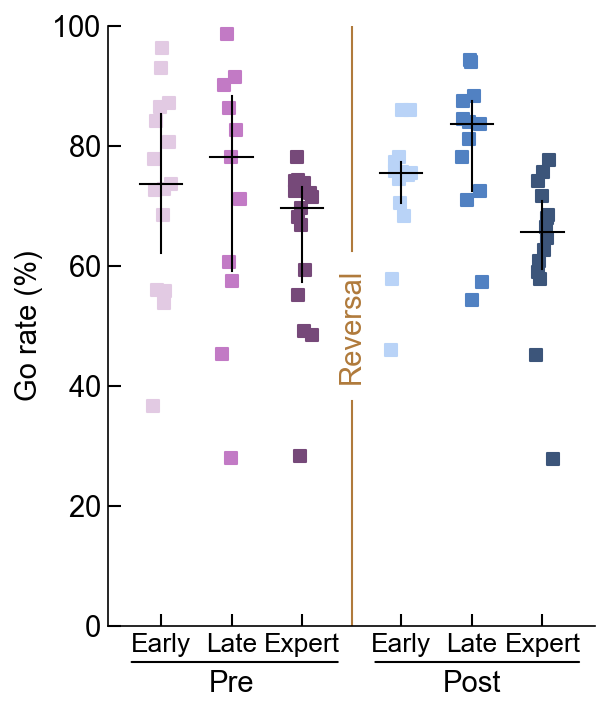

In [8]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(3.25, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.2
################################################################################################################

#Plot figure

data = data_go
labels = ['Early','Late','Expert','Early','Late','Expert']
numCon = len(data)

sz = 35
width = 0.3

for idx,column in enumerate(data):
    Y = ilep.rmnan(column)
    X = np.random.uniform(-width/2,width/2,size=len(Y)) + idx
    
    
    mean = np.mean(Y)
    [q1,mean,q3] = np.percentile(Y,[25,50,75])
    
    SEM = sem(Y)

    
    if idx<3:
        ax.scatter(X-switch_offset,Y,s=sz,color=PHASE_COLORS[idx],marker='s',clip_on=False)
        ax.plot([idx-switch_offset-width,idx-switch_offset+width],[mean]*2,color='k',lw=1)
        ax.plot([idx-switch_offset]*2,[q1,q3],color='k',lw=1)
        
    else:
        ax.scatter(X+switch_offset,Y,s=sz,color=PHASE_COLORS[idx],marker='s',clip_on=False)
        ax.plot([idx+switch_offset-width,idx+switch_offset+width],[mean]*2,color='k',lw=1)
        ax.plot([idx+switch_offset]*2,[q1,q3],color='k',lw=1)

    
################################################################################################################

labels = ['Early','Late','Expert','Early','Late','Expert']

ax.set_ylim([0,100])
ylab = ax.set_ylabel('Go rate (%)')

ax.set_xlim([-0.75-switch_offset,5.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2-switch_offset,3+switch_offset,4+switch_offset,5+switch_offset])
ax.set_xticklabels(labels)
# xlab = ax.set_xlabel('Example X label')

xtick_pos_pre = ax.get_xticks()[1]
xtick_pos_post = ax.get_xticks()[4]
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac)
t1 = ax.text(xtick_pos_pre, Yval, 'Pre', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Post', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.04, -stdyfrac), xycoords='axes fraction', xytext=(0.48, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.54, -stdyfrac), xycoords='axes fraction', xytext=(0.975, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

### Linear
Y = np.mean(ax.get_ylim())
t = ax.text(2.5,Y,'Reversal',rotation=90,fontsize=stdfont,color=SWITCH_COLOR,horizontalalignment='center',verticalalignment='center')
ax.plot([2.5]*2,[ax.get_ylim()[0],Y-np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)
ax.plot([2.5]*2,[ax.get_ylim()[1],Y+np.ptp(ax.get_ylim())*0.125],lw=1,color=SWITCH_COLOR)

artists = [ylab,t1,t2]
# fig.savefig(os.path.join('..','..','Figures','Figure 2k.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [11]:
data_go = SimpleNamespace()
data_go.preearly = go_preearly_value
data_go.prelate = go_prelate_value
data_go.preexpert = go_preexpert_value
data_go.postearly = go_postearly_value
data_go.postlate = go_postlate_value
data_go.postexpert = go_postexpert_value
ilep.ttestindcompareall(data_go)

pre-early   n = 15
pre-late    n = 11
pre-expert  n = 15
post-early  n = 13
post-late   n = 13
post-expert n = 14
pre-early  to pre-late   : 0.8742540397638442
pre-late   to pre-expert : 0.3344090752982008
pre-early  to pre-expert : 0.23710474602300538
post-early to post-late  : 0.26035696338505465
post-late  to post-expert: 0.016677798545755528
post-early to post-expert: 0.12414033807885065
